In [83]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
CSV_PATH = "songs_spotify.csv"


cluster_features =['acousticness', 'danceability', 'energy', 'instrumentalness', 
                  'liveness', 'loudness', 'speechiness', 'tempo', 'valence']
audio_features = cluster_features + ['popularity']

   

In [84]:
def find_and_remove_duplicates(df) :
    duplicate_ids = df.duplicated(subset=['id']).sum()
    print(f"Number of duplicate IDs found: {duplicate_ids}")
    df = df.drop(columns=['Unnamed: 0'], errors='ignore')   
    duplicate_uris = df.duplicated(subset=['uri']).sum()
    print(f"Number of duplicate URIs found: {duplicate_uris}")
    df = df.drop_duplicates(subset=['id'])
    df = df.drop_duplicates(subset=['uri'])
    print("\nMissing values per column:")
    print(df.isnull().sum())
    df = df.dropna()
        
    required_cols = list(set(cluster_features + ['popularity', 'duration_ms', 'release_date', 'album', 'name', 'id', 'uri']))
    existing_required = [c for c in required_cols if c in df.columns]
    df = df.dropna(subset=existing_required)

    if 'duration_ms' in df.columns:
        df['duration_min'] = df['duration_ms'] / 60000.0

    if 'release_date' in df.columns:
        df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
        df = df.dropna(subset=['release_date'])
        df['year'] = df['release_date'].dt.year.astype(int)

    return df


    

In [86]:
def normalize_album_name(album: str):
    if not isinstance(album, str):
        return album
    ## for simplicity, removing anything in parentheses
    base = re.sub(r"\s*\(.*?\)\s*", "", album).strip()
    return base

In [88]:
def visualize_top_albums_by_popular_songs(df, quantile = 0.75):
    pop_threshold = df['popularity'].quantile(quantile)
    popular_songs = df[df['popularity'] >= pop_threshold].copy()

    popular_songs['album_base'] = popular_songs['album'].apply(normalize_album_name)

    top_albums = popular_songs['album_base'].value_counts().head(10).reset_index()
    top_albums.columns = ['album', 'popular_song_count']

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_albums, y='album', x='popular_song_count', palette='viridis', hue='popular_song_count')
    plt.title(f'Top Albums by Count of Popular Songs (>= {int(pop_threshold)})')
    plt.xlabel('Number of Popular Songs')
    plt.ylabel('Album (normalized)')
    plt.tight_layout()
    plt.show()

    print("-" * 60)
    print("RECOMMENDATION (Top 2 Albums based on popular song count):")
    if len(top_albums) >= 2:
        print(f"1. {top_albums.iloc[0]['album']}  (count={top_albums.iloc[0]['popular_song_count']})")
        print(f"2. {top_albums.iloc[1]['album']}  (count={top_albums.iloc[1]['popular_song_count']})")
    elif len(top_albums) == 1:
        print(f"1. {top_albums.iloc[0]['album']}  (count={top_albums.iloc[0]['popular_song_count']})")
    else:
        print("No albums found under the chosen popularity threshold logic.")
    print("-" * 60)


In [108]:
def check_for_popularity_trends(df):
    if 'year' not in df.columns:
        print("Year column missing; cannot plot popularity trend.")
        return

    yearly_popularity = df.groupby('year')['popularity'].mean().reset_index()

    print("\nOBSERVATION ON POPULARITY TRENDS:")
    print("This line chart shows how average popularity changes by release year.")

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=yearly_popularity, x='year', y='popularity', marker='o')
    plt.title('Average Song Popularity Over Years')
    plt.xlabel('Year')
    plt.ylabel('Average Popularity')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [109]:
def find_correlation_between_audio_features(df) :
  
    corr_matrix = df[audio_features].corr(numeric_only=True)
    plt.figure(figsize=(12, 8))
    sns.heatmap( corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap of Audio Features')
    plt.tight_layout()
    plt.show()

In [111]:
def perform_dimensionality_reduction(df) :
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df[cluster_features])
    pca = PCA(n_components=2, random_state=42)
    df_pca = pca.fit_transform(df_scaled)
    df = df.copy()
    df['PCA1'] = df_pca[:, 0]
    df['PCA2'] = df_pca[:, 1]

    print(f"Original number of clustering features: {len(cluster_features)}")
    print(f"Number of features after PCA: {df_pca.shape[1]}")
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Total explained variance (2 PCs):", pca.explained_variance_ratio_.sum())

    return df_scaled, df
    return df_scaled, df

In [112]:
def pca_diagnostics(df, features):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])

    pca = PCA(n_components=2, random_state=42)
    Xp = pca.fit_transform(X)

    # Explained variance ratio
    evr = pca.explained_variance_ratio_
    print("Explained variance ratio (PC1, PC2):", evr)
    print("Total variance explained by 2 PCs:", evr.sum())

    # PCA loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=["PC1_loading", "PC2_loading"],
        index=features
    )
    print("\nTop drivers of PC1 (absolute):")
    print(loadings["PC1_loading"].abs().sort_values(ascending=False).head(5))

    print("\nTop drivers of PC2 (absolute):")
    print(loadings["PC2_loading"].abs().sort_values(ascending=False).head(5))

    # Add PCA components to dataframe
    df = df.copy()
    df["PCA1"] = Xp[:, 0]
    df["PCA2"] = Xp[:, 1]
    return X, df, loadings

In [113]:
def perform_clustering_analysis(df_scaled, k_min = 2, k_max = 10):
    inertias = []
    silhouettes = []
    K_range = range(k_min, k_max + 1)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(df_scaled)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(df_scaled, labels))

    # Elbow plot
    plt.figure(figsize=(10, 5))
    plt.plot(list(K_range), inertias, marker='o')
    plt.title('Elbow Method (Inertia) for k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Silhouette plot
    plt.figure(figsize=(10, 5))
    plt.plot(list(K_range), silhouettes, marker='o')
    plt.title('Silhouette Score for k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    best_k = list(K_range)[int(np.argmax(silhouettes))]
    best_score = float(np.max(silhouettes))
    print(f"Best k by silhouette: {best_k} (score={best_score:.4f})")

    return best_k, pd.DataFrame({"k": list(K_range), "inertia": inertias, "silhouette": silhouettes})


In [114]:
def fit_final_kmeans(df_scaled, df, k_optimal):
    kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
    df = df.copy()
    df['cluster'] = kmeans.fit_predict(df_scaled)
    return df, kmeans


In [115]:
def visualize_clusters(df, k_optimal):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='cluster', palette='Set2', s=50)
    plt.title(f'Song Cohorts (k={k_optimal}) Visualized with PCA')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\nCluster sizes:")
    print(df['cluster'].value_counts().sort_index())

In [116]:
def calculate_mean_of_features_per_cluster(df):
    cluster_means = df.groupby('cluster')[audio_features].mean()
    print("\nMean features per cluster (includes popularity for interpretation):")
    print(cluster_means)
    return cluster_means

In [117]:
def describe_clusters(df, top_n = 3):
    """
    printing a human-friendly description of each cluster by comparing cluster means
    vs global mean (z-like idea without dividing by std).
    """
    global_mean = df[cluster_features].mean()
    cluster_mean = df.groupby('cluster')[cluster_features].mean()

    print("\nCLUSTER DESCRIPTIONS (relative to global mean):")
    for c in sorted(cluster_mean.index):
        diff = (cluster_mean.loc[c] - global_mean).sort_values()
        low_feats = diff.head(top_n)
        high_feats = diff.tail(top_n)

        print("\n" + "-" * 60)
        print(f"Cluster {c}")
        print("Higher than average:", ", ".join([f"{k} (+{v:.3f})" for k, v in high_feats.items()]))
        print("Lower than average :", ", ".join([f"{k} ({v:.3f})" for k, v in low_feats.items()]))

        # Popularity stats
        pop_mean = df[df['cluster'] == c]['popularity'].mean()
        pop_med = df[df['cluster'] == c]['popularity'].median()
        print(f"Popularity mean/median: {pop_mean:.2f} / {pop_med:.2f}")

        #Few example songs
        example = df[df['cluster'] == c].sort_values('popularity', ascending=False)[['name', 'album', 'year', 'popularity']].head(5)
        print("\nTop 5 songs in this cluster by popularity:")
        print(example.to_string(index=False))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


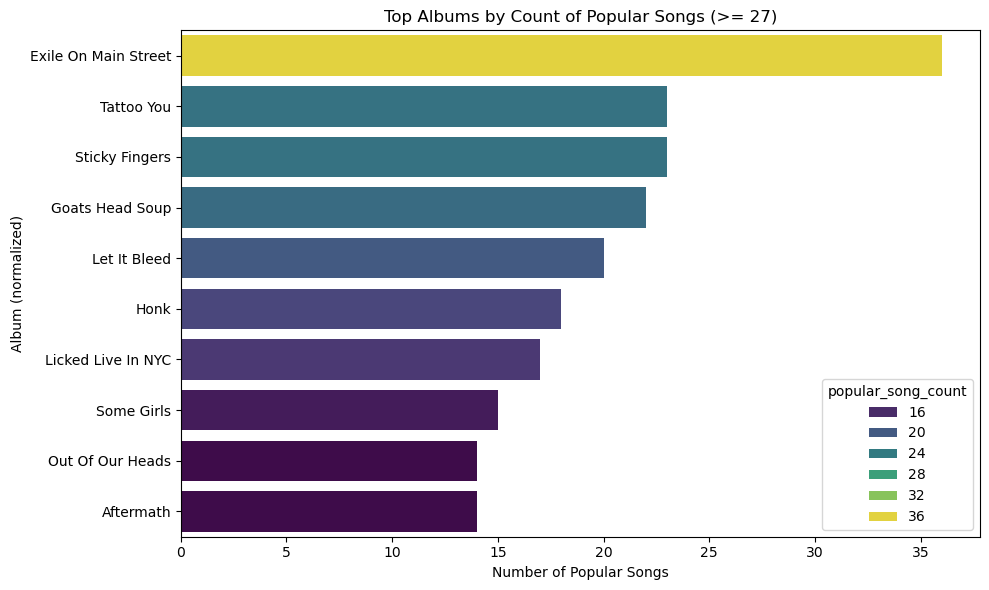

------------------------------------------------------------
RECOMMENDATION (Top 2 Albums based on popular song count):
1. Exile On Main Street  (count=36)
2. Tattoo You  (count=23)
------------------------------------------------------------


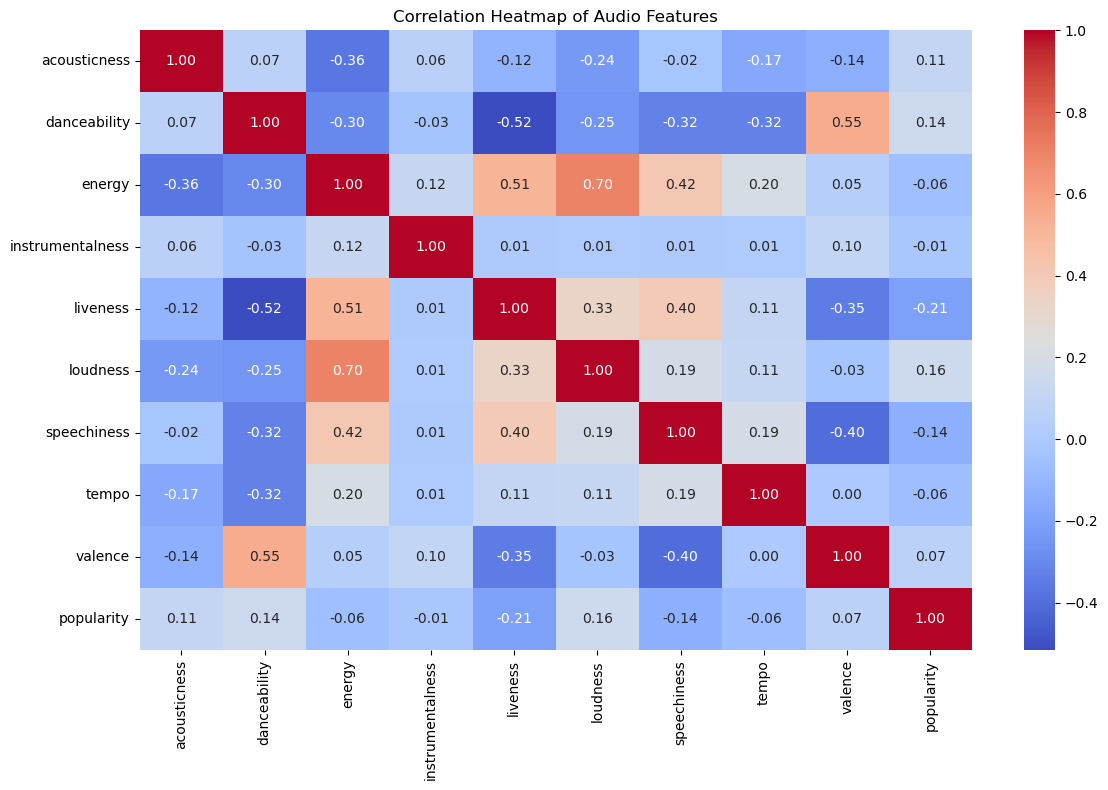


OBSERVATION ON POPULARITY TRENDS:
This line chart shows how average popularity changes by release year.


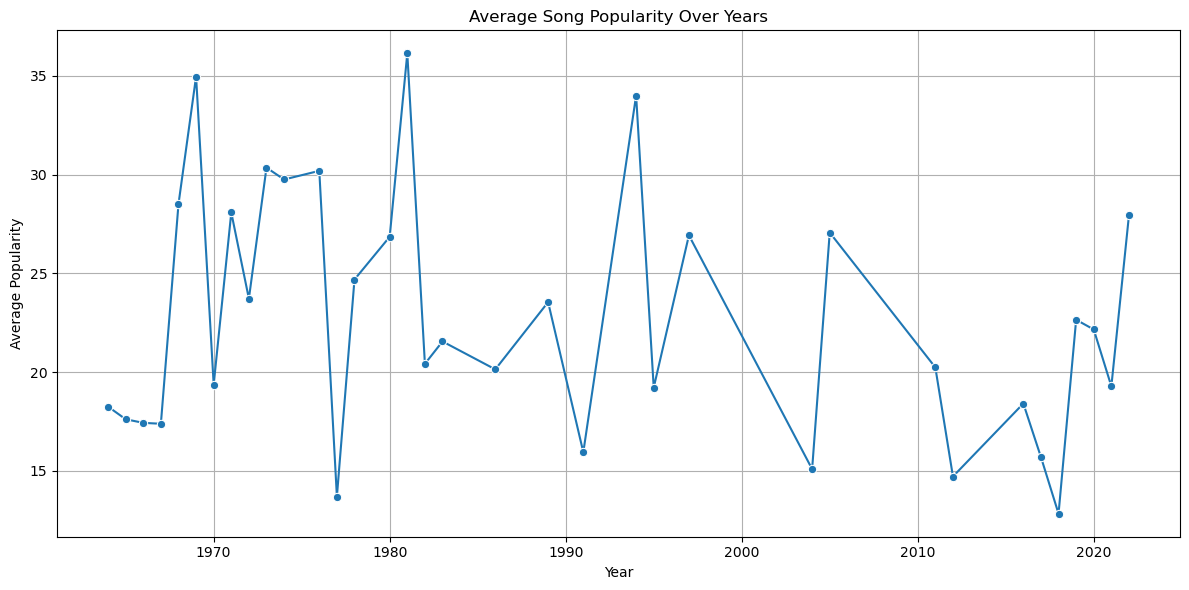

Original number of clustering features: 9
Number of features after PCA: 2
Explained variance ratio: [0.32446344 0.17938047]
Total explained variance (2 PCs): 0.5038439118326266
Explained variance ratio (PC1, PC2): [0.32446344 0.17938047]
Total variance explained by 2 PCs: 0.5038439118326266

Top drivers of PC1 (absolute):
energy          0.451613
liveness        0.443919
danceability    0.418271
speechiness     0.375195
loudness        0.369900
Name: PC1_loading, dtype: float64

Top drivers of PC2 (absolute):
valence         0.597875
acousticness    0.448240
energy          0.386237
loudness        0.357042
danceability    0.300597
Name: PC2_loading, dtype: float64


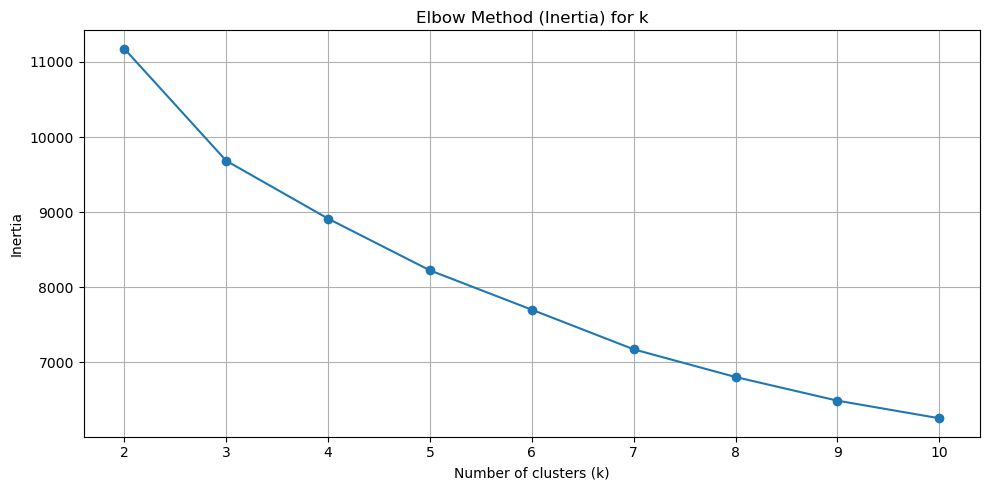

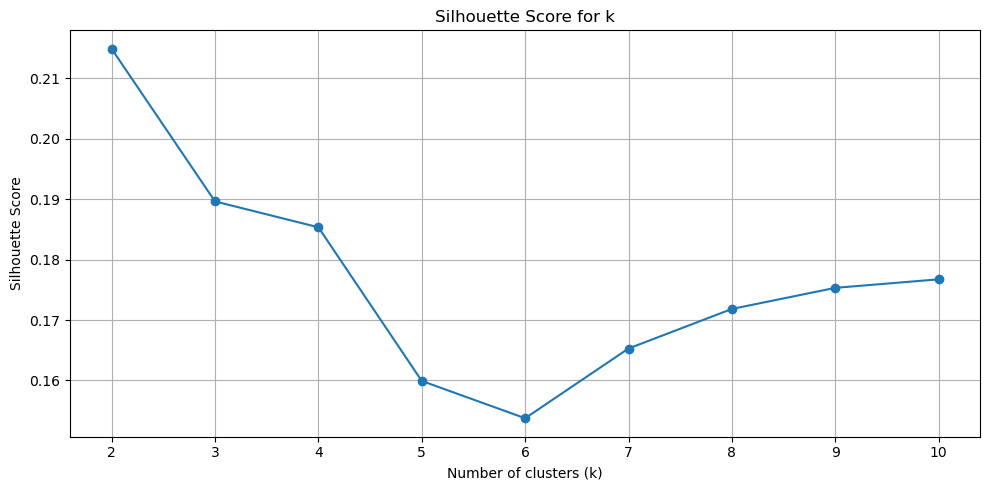

Best k by silhouette: 2 (score=0.2149)


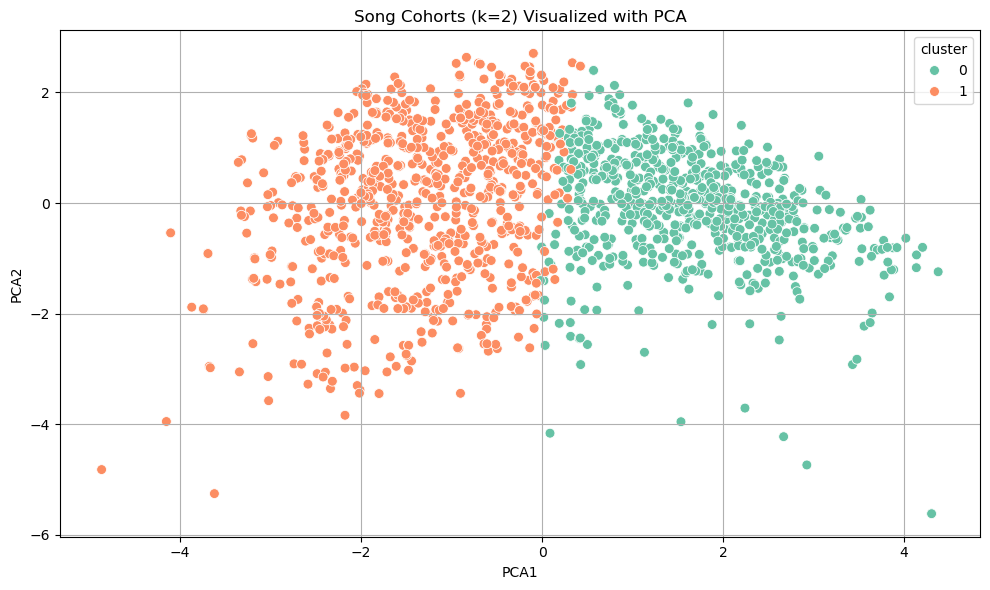


Cluster sizes:
cluster
0    709
1    901
Name: count, dtype: int64

Mean features per cluster (includes popularity for interpretation):
         acousticness  danceability    energy  instrumentalness  liveness  \
cluster                                                                     
0            0.189781      0.371403  0.915883          0.157852  0.791713   
1            0.298235      0.545548  0.695145          0.169141  0.255671   

         loudness  speechiness       tempo   valence  popularity  
cluster                                                           
0       -5.444650     0.098073  135.765780  0.482813   18.222849  
1       -8.173189     0.047038  118.461859  0.660347   22.806881  

CLUSTER DESCRIPTIONS (relative to global mean):

------------------------------------------------------------
Cluster 0
Higher than average: liveness (+0.300), loudness (+1.527), tempo (+9.684)
Lower than average : valence (-0.099), danceability (-0.097), acousticness (-0.061)
Popular

In [118]:
songs_df = pd.read_csv(CSV_PATH)
songs_df.head()
songs_df.info()
songs_df = find_and_remove_duplicates(songs_df)
visualize_top_albums_by_popular_songs(songs_df, quantile=0.75)
find_correlation_between_audio_features(songs_df)
check_for_popularity_trends(songs_df)

df_scaled, songs_df = perform_dimensionality_reduction(songs_df)
df_scaled, songs_df, pca_loadings = pca_diagnostics(songs_df, cluster_features)

k_optimal, k_report = perform_clustering_analysis(df_scaled, k_min=2, k_max=10)
songs_df, model = fit_final_kmeans(df_scaled, songs_df, k_optimal)

visualize_clusters(songs_df, k_optimal)
cluster_means = calculate_mean_of_features_per_cluster(songs_df)
describe_clusters(songs_df, top_n=3)